# Busca Binaria: Melhor Caso, Pior Caso e Caso Medio

Este notebook analisa e compara graficamente as tres eficiencias da **busca binaria** em vetor ordenado:

| Caso | Condicao | Custo |
|------|----------|-------|
| **Melhor caso** | item esta no meio na 1a iteracao | $C_{best}(n) = 1$ |
| **Pior caso** | item ausente ou encontrado na maior profundidade | $C_{worst}(n) = \lfloor \log_2 n \rfloor + 1$ |
| **Caso medio (aprox.)** | sucesso com probabilidade $p$ | $C_{avg}(n) \approx p\log_2(n) + (1-p)(\lfloor\log_2 n\rfloor+1)$ |

Para $p = 1$ (busca sempre bem-sucedida): $C_{avg}(n) \approx \log_2(n)$

---

## 1) Configuracao e importacoes

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")

# Tamanhos de entrada avaliados
TAMANHOS = list(range(1, 501))

# Probabilidade de busca bem-sucedida usada no caso medio aproximado
P = 1.0   # p=1 -> C_avg ~ log2(n) ; altere para ver outros cenarios

## 2) Busca binaria instrumentada

A funcao retorna o indice encontrado **e** o numero de comparacoes com o elemento do meio.

In [ ]:
def busca_binaria(arr, chave):
    """
    Busca binaria com contagem da operacao basica (comparacao com arr[meio]).
    Retorna (indice_encontrado_ou_-1, numero_de_comparacoes).
    """
    esquerda, direita = 0, len(arr) - 1
    comparacoes = 0

    while esquerda <= direita:
        meio = (esquerda + direita) // 2
        comparacoes += 1

        if arr[meio] == chave:
            return meio, comparacoes
        if chave < arr[meio]:
            direita = meio - 1
        else:
            esquerda = meio + 1

    return -1, comparacoes

## 3) Formulas teoricas

Calculamos as curvas teoricas de cada caso para comparar com os valores empiricos.

In [ ]:
ns = np.array(TAMANHOS)

# Teorico
teorico_melhor = np.ones_like(ns, dtype=float)
teorico_pior = np.floor(np.log2(ns)) + 1
teorico_medio = P * np.log2(ns) + (1 - P) * teorico_pior

print(f"Para p = {P}:")
print("  Melhor caso: C_best = 1  (Theta(1))")
print("  Pior caso:   C_worst = floor(log2(n)) + 1  (Theta(log n))")
print("  Caso medio (aprox.): C_avg = p*log2(n) + (1-p)*(floor(log2(n))+1)")
print("  -> Para p=1: C_avg ~ log2(n)")

Para p = 1.0:
  Melhor caso: C_best = 1  (Θ(1))
  Pior caso:   C_worst = n  (Θ(n))
  Caso médio:  C_avg = p(n+1)/2 + n(1-p)
  → Para p=1: C_avg = (n+1)/2  ≈  n/2


## 4) Contagem empirica de comparacoes

Executamos a busca nos tres cenarios reais e registramos o numero de comparacoes para validar as formulas:

In [ ]:
REPETICOES_MEDIO = 200   # amostras para estimar o caso medio

emp_melhor = []
emp_pior = []
emp_medio = []

for n in TAMANHOS:
    arr = list(range(n))   # elementos 0..n-1 distintos e ordenados

    # --- Melhor caso: chave exatamente no meio inicial
    chave_melhor = arr[(n - 1) // 2]
    _, c = busca_binaria(arr, chave_melhor)
    emp_melhor.append(c)

    # --- Pior caso: chave ausente
    _, c = busca_binaria(arr, -1)
    emp_pior.append(c)

    # --- Caso medio (p=1): item sempre presente, posicao uniforme
    total = 0
    for _ in range(REPETICOES_MEDIO):
        chave = random.randrange(n)
        _, c = busca_binaria(arr, chave)
        total += c
    emp_medio.append(total / REPETICOES_MEDIO)

emp_melhor = np.array(emp_melhor)
emp_pior = np.array(emp_pior)
emp_medio = np.array(emp_medio)

print("Amostra (n=100):")
print(f"  Melhor caso empirico:  {emp_melhor[99]:.1f}  | teorico: {teorico_melhor[99]:.1f}")
print(f"  Pior caso empirico:    {emp_pior[99]:.1f}  | teorico: {teorico_pior[99]:.1f}")
print(f"  Caso medio empirico:   {emp_medio[99]:.1f}  | teorico aprox.: {teorico_medio[99]:.1f}")

Amostra (n=100):
  Melhor caso empírico:  1.0  | teórico: 1.0
  Pior caso empírico:    100.0  | teórico: 100.0
  Caso médio empírico:   49.1  | teórico: 50.5


## 5) Tabela resumida

In [ ]:
pontos = [1, 10, 50, 100, 200, 500]
idx = [n - 1 for n in pontos]

df = pd.DataFrame({
    "n": pontos,
    "melhor_teorico": teorico_melhor[idx].astype(int),
    "melhor_empirico": emp_melhor[idx].astype(int),
    "medio_teorico_aprox": teorico_medio[idx].round(2),
    "medio_empirico": emp_medio[idx].round(2),
    "pior_teorico": teorico_pior[idx].astype(int),
    "pior_empirico": emp_pior[idx].astype(int),
})
df

,n,melhor_teórico,melhor_empírico,médio_teórico,médio_empírico,pior_teórico,pior_empírico
0,1,1,1,1.0,1.0,1,1
1,10,1,1,5.5,5.7,10,10
2,50,1,1,25.5,26.6,50,50
3,100,1,1,50.5,49.1,100,100
4,200,1,1,100.5,100.9,200,200
5,500,1,1,250.5,244.5,500,500


## 6) Grafico principal: comparacoes x tamanho da entrada

Curvas teoricas (linhas solidas) sobrepostas com os valores empiricos (marcadores pontilhados) para validacao visual.

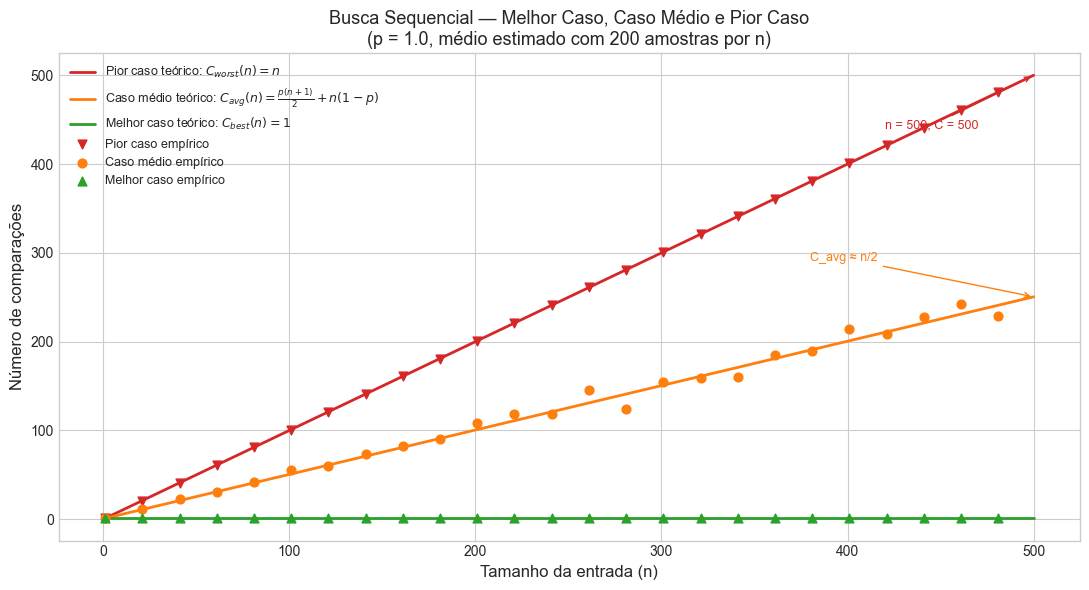

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

# Curvas teoricas (linhas cheias)
ax.plot(ns, teorico_pior, color="#d62728", linewidth=2, label=r"Pior caso teorico: $C_{worst}(n)=\lfloor\log_2 n\rfloor+1$")
ax.plot(ns, teorico_medio, color="#ff7f0e", linewidth=2, label=r"Caso medio teorico (aprox.): $C_{avg}(n)\approx p\log_2(n)+(1-p)(\lfloor\log_2 n\rfloor+1)$")
ax.plot(ns, teorico_melhor, color="#2ca02c", linewidth=2, label=r"Melhor caso teorico: $C_{best}(n)=1$")

# Pontos empiricos (marcadores esparsos para nao poluir)
passo = 20
ax.scatter(ns[::passo], emp_pior[::passo], color="#d62728", marker="v", s=40, zorder=5, label="Pior caso empirico")
ax.scatter(ns[::passo], emp_medio[::passo], color="#ff7f0e", marker="o", s=40, zorder=5, label="Caso medio empirico")
ax.scatter(ns[::passo], emp_melhor[::passo], color="#2ca02c", marker="^", s=40, zorder=5, label="Melhor caso empirico")

# Anotacoes
ax.annotate(f"n = {ns[-1]}, C ~ {teorico_pior[-1]:.0f}",
            xy=(ns[-1], teorico_pior[-1]),
            xytext=(ns[-1] - 130, teorico_pior[-1] - 2.5),
            arrowprops=dict(arrowstyle="->", color="#d62728"),
            color="#d62728", fontsize=9)

ax.annotate("C_avg ~ log2(n)",
            xy=(ns[-1], teorico_medio[-1]),
            xytext=(ns[-1] - 180, teorico_medio[-1] + 1.8),
            arrowprops=dict(arrowstyle="->", color="#ff7f0e"),
            color="#ff7f0e", fontsize=9)

ax.set_xlabel("Tamanho da entrada (n)", fontsize=12)
ax.set_ylabel("Numero de comparacoes", fontsize=12)
ax.set_title("Busca Binaria - Melhor Caso, Caso Medio e Pior Caso\n"
             f"(p = {P}, medio estimado com {REPETICOES_MEDIO} amostras por n)", fontsize=13)
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
plt.tight_layout()
plt.show()

## 7) Explorando diferentes valores de p

Altere o valor de `p` abaixo para ver como o **caso medio** se desloca entre o melhor e o pior caso.

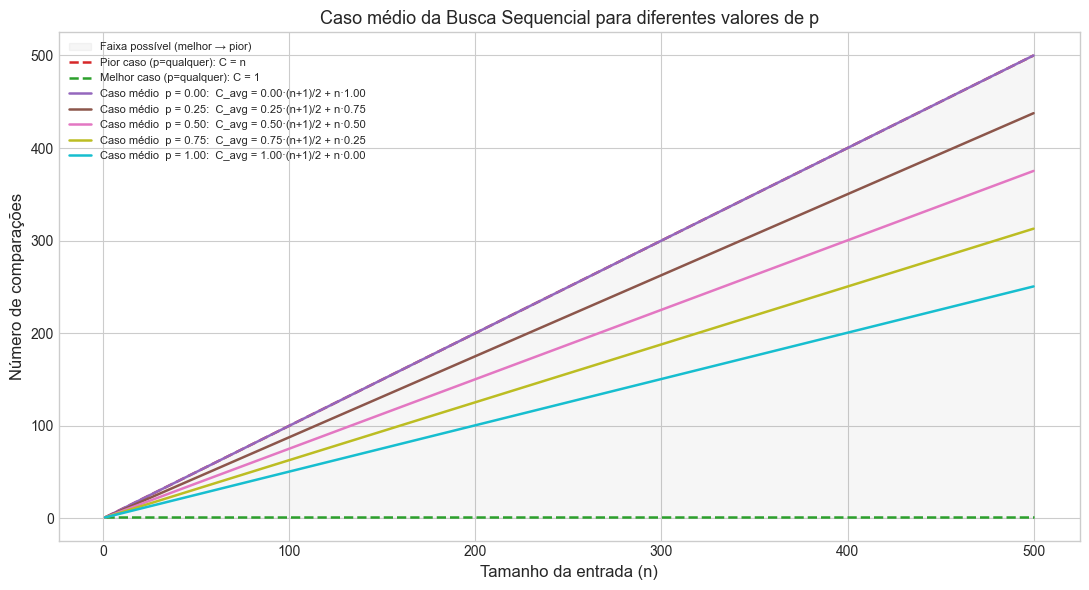

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

valores_p = [0.0, 0.25, 0.50, 0.75, 1.0]
cores_p = ["#9467bd", "#8c564b", "#e377c2", "#bcbd22", "#17becf"]

# Pior e melhor como faixa de referencia
ax.fill_between(ns, teorico_melhor, teorico_pior,
                alpha=0.07, color="gray", label="Faixa possivel (melhor -> pior)")
ax.plot(ns, teorico_pior, color="#d62728", linewidth=1.8, linestyle="--",
        label=r"Pior caso: $\lfloor\log_2 n\rfloor+1$")
ax.plot(ns, teorico_melhor, color="#2ca02c", linewidth=1.8, linestyle="--",
        label=r"Melhor caso: $1$")

for p_val, cor in zip(valores_p, cores_p):
    c_avg = p_val * np.log2(ns) + (1 - p_val) * (np.floor(np.log2(ns)) + 1)
    ax.plot(ns, c_avg, color=cor, linewidth=1.8,
            label=f"Caso medio aprox. p = {p_val:.2f}: p*log2(n)+(1-p)*(floor(log2(n))+1)")

ax.set_xlabel("Tamanho da entrada (n)", fontsize=12)
ax.set_ylabel("Numero de comparacoes", fontsize=12)
ax.set_title("Caso medio aproximado da Busca Binaria para diferentes valores de p", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
plt.tight_layout()
plt.show()

## Conclusao

| Caso | Custo | Classe | Interpretacao |
|------|-------|--------|---------------|
| **Melhor** | $C_{best}(n) = 1$ | $\Theta(1)$ | Chave esta no meio ja na 1a iteracao |
| **Medio** (p=1, aprox.) | $C_{avg}(n) \approx \log_2(n)$ | $\Theta(\log n)$ | Busca bem-sucedida em posicao equiprovavel |
| **Pior** | $C_{worst}(n)=\lfloor\log_2 n\rfloor+1$ | $\Theta(\log n)$ | Item ausente ou encontrado na maior profundidade |

> **Observacao importante**: na busca binaria, caso medio e pior caso permanecem em $\Theta(\log n)$ e sao muito menores que os custos lineares da busca sequencial para entradas grandes.